# Metaclonotype Clustering — Method Comparison

This notebook demonstrates and compares different metaclonotype clustering methods
available in mirpy:

| Method | Algorithm type | Paired support |
|---|---|---|
| `edit_distance` | Graph (Hamming/Levenshtein + Leiden/components) | Via chain-combine |
| `alice` | Enrichment-based seed neighbors | Via chain-combine |
| `tcrnet` | Enrichment-based seed neighbors | Via chain-combine |
| `tcrdist` | Continuous radius threshold | Via chain-combine |
| `tcremp` | Embedding + DBSCAN/OPTICS | Native paired embedding |
| `gliph` | k-mer token graph | Via chain-combine |

**Workflow:**
1. Load a benchmark TRB repertoire.
2. Compute clonotype diversity (baseline).
3. Cluster with each method → compute functional diversity.
4. Compare functional Hill curves across methods.
5. Load paired TRA/TRB data → compare TCREmp native paired vs edit-distance chain-combined.
6. Measure concordance between paired strategies.

---
**Required assets:** AIRR benchmark data (run `ensure_airr_benchmark()` once to download).

In [1]:
# Cell 1: Environment versions
import platform, sys, importlib
print('Python', sys.version)
for pkg in ['mir', 'polars', 'numpy', 'sklearn', 'igraph']:
    try:
        m = importlib.import_module(pkg)
        print(f'{pkg} {getattr(m, "__version__", "?")}', end='  ')
    except ImportError:
        print(f'{pkg} NOT INSTALLED', end='  ')
print('\nPlatform', platform.machine())

Python 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]
mir ?  polars 1.40.1  numpy 1.26.4  

sklearn 1.8.0  igraph 1.0.0  
Platform arm64


In [2]:
# Cell 2: Imports
import time
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mir.biomarkers.metaclonotype_cluster import (
    MetaclonotypeClusterConfig,
    cluster_metaclonotypes,
    cluster_paired_metaclonotypes,
)
from mir.common.metaclonotype import (
    functional_diversity,
    functional_hill_curve,
    summarize_metaclonotypes,
)
from mir.common.diversity import summarize_clonotypes, hill_curve_clonotypes
from mir.utils import ensure_airr_benchmark

/Users/mikesh/vcs/mirpy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Cell 3: Load benchmark data (VDJtools aging cohort)
from pathlib import Path
from mir.utils import ensure_airr_benchmark
from mir.utils.notebook_assets import notebook_large_assets_root

repo_root = Path('.').resolve()
benchmark_root = ensure_airr_benchmark(allow_patterns=['vdjtools/**'])
vdjtools_dir = benchmark_root / 'vdjtools'
meta_path = vdjtools_dir / 'metadata_aging.txt'

import polars as pl
meta_df = pl.read_csv(meta_path, separator='\t')
rename_map = {c: c.lstrip('#') for c in meta_df.columns if c.startswith('#')}
if rename_map:
    meta_df = meta_df.rename(rename_map)
print(f'Aging metadata: {meta_df.height} donors, age {meta_df["age"].min()}–{meta_df["age"].max()}')
print(meta_df.head(5))

Fetching 322 files:   0%|          | 0/322 [00:00<?, ?it/s]

Fetching 322 files:  81%|████████▏ | 262/322 [00:00<00:00, 2604.55it/s]

Fetching 322 files: 100%|██████████| 322/322 [00:00<00:00, 2656.78it/s]

Aging metadata: 79 donors, age 0–103
shape: (5, 5)
┌─────────────┬───────────┬─────┬─────┬────────┐
│ file_name   ┆ sample_id ┆ sex ┆ age ┆ label  │
│ ---         ┆ ---       ┆ --- ┆ --- ┆ ---    │
│ str         ┆ str       ┆ str ┆ i64 ┆ str    │
╞═════════════╪═══════════╪═════╪═════╪════════╡
│ A3-i101.txt ┆ A3-i101   ┆ F   ┆ 36  ┆ p1-F36 │
│ A3-i102.txt ┆ A3-i102   ┆ F   ┆ 43  ┆ p2-F43 │
│ A3-i106.txt ┆ A3-i106   ┆ F   ┆ 43  ┆ p3-F43 │
│ A3-i107.txt ┆ A3-i107   ┆ F   ┆ 39  ┆ p4-F39 │
│ A3-i110.txt ┆ A3-i110   ┆ F   ┆ 34  ┆ p5-F34 │
└─────────────┴───────────┴─────┴─────┴────────┘


In [4]:
# Cell 4: Parse and downsample a single TRB repertoire for single-chain comparisons
from mir.common.parser import VDJtoolsParser
from mir.common.repertoire import LocusRepertoire
from mir.common.sampling import downsample

# Pick first adult sample (age > 0) for a representative but not cord-blood example
adult_rows = meta_df.filter(pl.col('age') > 0)
file_name = adult_rows['file_name'][0]
sample_id = adult_rows['sample_id'][0]

# Resolve file (try both compressed and uncompressed)
sample_path = None
for cand in [file_name, file_name + '.gz', file_name.replace('.txt', '.txt.gz')]:
    p = vdjtools_dir / cand
    if p.exists():
        sample_path = p
        break
assert sample_path is not None, f'Cannot find {file_name} in {vdjtools_dir}'

parser = VDJtoolsParser(sep='\t')
clonotypes = parser.parse(str(sample_path))
rep_full = LocusRepertoire(clonotypes=clonotypes, locus='TRB')

# Downsample to 30k reads to keep method-comparison tractable (graph build is O(n²))
DEMO_READS = 30_000
rep = downsample(rep_full, DEMO_READS, random_seed=42)
print(f'Loaded {rep_full.clonotype_count:,} clonotypes from {sample_path.name}')
print(f'Downsampled to {rep.clonotype_count:,} clonotypes @ {DEMO_READS:,} reads  (sample_id={sample_id})')

Loaded 1,150,027 clonotypes from A3-i101.txt.gz
Downsampled to 25,290 clonotypes @ 30,000 reads  (sample_id=A3-i101)


In [5]:
# Cell 5: Baseline clonotype diversity
div_baseline = summarize_clonotypes(rep.clonotypes)
print('Baseline diversity:')
for field in ['abundance', 'diversity', 'shannon', 'gini_simpson', 'chao1']:
    print(f'  {field}: {getattr(div_baseline, field):.3f}')

Baseline diversity:
  abundance: 30000.000
  diversity: 25290.000
  shannon: 9.620
  gini_simpson: 0.998
  chao1: 430429.187


In [6]:
# Cell 6: Edit-distance graph metaclonotypes (components and Leiden)
results = {}

for graph_algo in ('components', 'leiden'):
    cfg = MetaclonotypeClusterConfig(
        method='edit_distance',
        metric='hamming',
        threshold=1,
        graph_algo=graph_algo,
        min_cluster_size=2,
        n_jobs=4,
    )
    t0 = time.perf_counter()
    meta = cluster_metaclonotypes(rep, cfg)
    elapsed = time.perf_counter() - t0
    div = functional_diversity(rep, meta)
    results[f'edit_distance/{graph_algo}'] = (meta, div, elapsed)
    print(f'edit_distance/{graph_algo}: clusters={meta.n_clusters}, '
          f'shannon={div.shannon:.3f}, elapsed={elapsed:.2f}s')

Skipping sequence with non-canonical amino acid: CASSLAL_SNYGYTF
Skipping sequence with non-canonical amino acid: CAS*SGTVRYGYTF
Skipping sequence with non-canonical amino acid: CATATSG_HTDTQYF
Skipping sequence with non-canonical amino acid: CASSQGL_QQETQYF
Skipping sequence with non-canonical amino acid: CASS*APG_F*EETQYF
Skipping sequence with non-canonical amino acid: CSAPLG_YGYTF
Skipping sequence with non-canonical amino acid: CAHPGGDRG_ERHQPQHF
Skipping sequence with non-canonical amino acid: CATSGA_GDTQYF
Skipping sequence with non-canonical amino acid: CASSSTPWD_CHGVCEQFF
Skipping sequence with non-canonical amino acid: CARK*RG_TQETQYF
Skipping sequence with non-canonical amino acid: CASSLPGQ_DFLETQYF
Skipping sequence with non-canonical amino acid: CAS*EGAGANVLTF
Skipping sequence with non-canonical amino acid: CATRLAG_HTDTQYF
Skipping sequence with non-canonical amino acid: CAMGR_EQYF
Skipping sequence with non-canonical amino acid: CAS_FF
Skipping sequence with non-canonica

Skipping sequence with non-canonical amino acid: CASSLAL_SNYGYTF
Skipping sequence with non-canonical amino acid: CAS*SGTVRYGYTF
Skipping sequence with non-canonical amino acid: CATATSG_HTDTQYF
Skipping sequence with non-canonical amino acid: CASSQGL_QQETQYF
Skipping sequence with non-canonical amino acid: CASS*APG_F*EETQYF
Skipping sequence with non-canonical amino acid: CSAPLG_YGYTF
Skipping sequence with non-canonical amino acid: CAHPGGDRG_ERHQPQHF
Skipping sequence with non-canonical amino acid: CATSGA_GDTQYF
Skipping sequence with non-canonical amino acid: CASSSTPWD_CHGVCEQFF
Skipping sequence with non-canonical amino acid: CARK*RG_TQETQYF
Skipping sequence with non-canonical amino acid: CASSLPGQ_DFLETQYF
Skipping sequence with non-canonical amino acid: CAS*EGAGANVLTF
Skipping sequence with non-canonical amino acid: CATRLAG_HTDTQYF
Skipping sequence with non-canonical amino acid: CAMGR_EQYF
Skipping sequence with non-canonical amino acid: CAS_FF
Skipping sequence with non-canonica

edit_distance/components: clusters=992, shannon=4.900, elapsed=5.68s


Skipping sequence with non-canonical amino acid: CASSLAL_SNYGYTF
Skipping sequence with non-canonical amino acid: CAS*SGTVRYGYTF
Skipping sequence with non-canonical amino acid: CATATSG_HTDTQYF
Skipping sequence with non-canonical amino acid: CASSQGL_QQETQYF
Skipping sequence with non-canonical amino acid: CASS*APG_F*EETQYF
Skipping sequence with non-canonical amino acid: CSAPLG_YGYTF
Skipping sequence with non-canonical amino acid: CAHPGGDRG_ERHQPQHF
Skipping sequence with non-canonical amino acid: CATSGA_GDTQYF
Skipping sequence with non-canonical amino acid: CASSSTPWD_CHGVCEQFF
Skipping sequence with non-canonical amino acid: CARK*RG_TQETQYF
Skipping sequence with non-canonical amino acid: CASSLPGQ_DFLETQYF
Skipping sequence with non-canonical amino acid: CAS*EGAGANVLTF
Skipping sequence with non-canonical amino acid: CATRLAG_HTDTQYF
Skipping sequence with non-canonical amino acid: CAMGR_EQYF
Skipping sequence with non-canonical amino acid: CAS_FF
Skipping sequence with non-canonica

Skipping sequence with non-canonical amino acid: CASSLAL_SNYGYTF
Skipping sequence with non-canonical amino acid: CAS*SGTVRYGYTF
Skipping sequence with non-canonical amino acid: CATATSG_HTDTQYF
Skipping sequence with non-canonical amino acid: CASSQGL_QQETQYF
Skipping sequence with non-canonical amino acid: CASS*APG_F*EETQYF
Skipping sequence with non-canonical amino acid: CSAPLG_YGYTF
Skipping sequence with non-canonical amino acid: CAHPGGDRG_ERHQPQHF
Skipping sequence with non-canonical amino acid: CATSGA_GDTQYF
Skipping sequence with non-canonical amino acid: CASSSTPWD_CHGVCEQFF
Skipping sequence with non-canonical amino acid: CARK*RG_TQETQYF
Skipping sequence with non-canonical amino acid: CASSLPGQ_DFLETQYF
Skipping sequence with non-canonical amino acid: CAS*EGAGANVLTF
Skipping sequence with non-canonical amino acid: CATRLAG_HTDTQYF
Skipping sequence with non-canonical amino acid: CAMGR_EQYF
Skipping sequence with non-canonical amino acid: CAS_FF
Skipping sequence with non-canonica

edit_distance/leiden: clusters=1012, shannon=5.322, elapsed=5.93s


In [7]:
# Cell 7: ALICE metaclonotypes (requires ALICE to be pre-run)
# Run ALICE enrichment first (Hamming-1 neighborhood enrichment is built in),
# then build metaclonotypes from significantly enriched clonotypes.
from mir.biomarkers.alice import add_alice_metadata

t0 = time.perf_counter()
rep_alice = add_alice_metadata(
    rep,
    species='human',
    metric='hamming',
    match_mode='vj',
    n_jobs=4,
)
t_alice_analysis = time.perf_counter() - t0

cfg_alice = MetaclonotypeClusterConfig(method='alice', q_value_max=0.05)
t0 = time.perf_counter()
meta_alice = cluster_metaclonotypes(rep_alice, cfg_alice)
t_alice_cluster = time.perf_counter() - t0

div_alice = functional_diversity(rep_alice, meta_alice)
results['alice'] = (meta_alice, div_alice, t_alice_analysis + t_alice_cluster)
print(f'ALICE: clusters={meta_alice.n_clusters}, '
      f'shannon={div_alice.shannon:.3f}, '
      f'analysis={t_alice_analysis:.2f}s, cluster={t_alice_cluster:.3f}s')

Skipping sequence with non-canonical amino acid: CSARGQRD_EFYEQYF
Skipping sequence with non-canonical amino acid: CSARDD_GYEQYF
Skipping sequence with non-canonical amino acid: CSARDRSAS_GWGYEQYF
Skipping sequence with non-canonical amino acid: CSAPNHP*RGLGKQYF
Skipping sequence with non-canonical amino acid: CSASEGD_GSYEQYF
Skipping sequence with non-canonical amino acid: CSASP*QGANEQYF
Skipping sequence with non-canonical amino acid: CSARDGTPSYE*YF
Skipping sequence with non-canonical amino acid: CSASRGT_PTEQYF
Skipping sequence with non-canonical amino acid: CSAGDRG_ILQQYF
Skipping sequence with non-canonical amino acid: CSAVASA_TYEQYF
Skipping sequence with non-canonical amino acid: CSARED*_WDEQYF
Skipping sequence with non-canonical amino acid: CSAAD_RMGYF
Skipping sequence with non-canonical amino acid: CASSRRTSG_DEVYEQYF
Skipping sequence with non-canonical amino acid: CASSLAR_EGGEQYF
Skipping sequence with non-canonical amino acid: CASSPRA_EGPEQYF
Skipping sequence with non-ca

ALICE: clusters=1636, shannon=7.269, analysis=7.36s, cluster=0.742s


In [ ]:
# Cell 8: TCRdist metaclonotypes
# Note: mirpy TcrDist raw scores are ~900 (min) to ~4000 (median) for random TRB repertoires.
# max_distance=1200 captures only the ~1-2% most similar pairs (near-identical CDR3 + V/J).
# TCRdist clustering is most effective on epitope-specific repertoires.
cfg_tcrdist = MetaclonotypeClusterConfig(
    method='tcrdist',
    locus='TRB',
    species='human',
    max_distance=1200.0,
    n_jobs=4,
)
t0 = time.perf_counter()
meta_tcrdist = cluster_metaclonotypes(rep, cfg_tcrdist)
elapsed = time.perf_counter() - t0

div_tcrdist = functional_diversity(rep, meta_tcrdist)
results['tcrdist'] = (meta_tcrdist, div_tcrdist, elapsed)
print(f'TCRdist (max_dist=1200): clusters={meta_tcrdist.n_clusters}, '
      f'shannon={div_tcrdist.shannon:.3f}, elapsed={elapsed:.2f}s')

In [ ]:
# Cell 9: TCREmp single-chain metaclonotypes (OPTICS — no eps calibration needed)
# The embedding is L2-normalized before clustering. Use OPTICS to avoid manual eps selection.
# For DBSCAN, eps should be calibrated via the k-NN elbow method (see tcremp notebooks).
cfg_tcremp = MetaclonotypeClusterConfig(
    method='tcremp',
    locus='TRB',
    species='human',
    n_prototypes=300,
    embed_cluster_algo='optics',
    optics_min_samples=5,
    n_jobs=4,
)
t0 = time.perf_counter()
meta_tcremp = cluster_metaclonotypes(rep, cfg_tcremp)
elapsed = time.perf_counter() - t0

div_tcremp = functional_diversity(rep, meta_tcremp)
results['tcremp'] = (meta_tcremp, div_tcremp, elapsed)
print(f'TCREmp OPTICS: clusters={meta_tcremp.n_clusters}, '
      f'shannon={div_tcremp.shannon:.3f}, elapsed={elapsed:.2f}s')

In [10]:
# Cell 10: Summary table — single-chain comparisons
rows = []
for method, (meta, div, elapsed) in results.items():
    rows.append({
        'method': method,
        'n_clusters': meta.n_clusters,
        'shannon': round(div.shannon, 3),
        'gini_simpson': round(div.gini_simpson, 3),
        'chao1': round(div.chao1, 1),
        'elapsed_s': round(elapsed, 2),
    })

# Baseline row
rows.insert(0, {
    'method': 'baseline (clonotypes)',
    'n_clusters': div_baseline.abundance,
    'shannon': round(div_baseline.shannon, 3),
    'gini_simpson': round(div_baseline.gini_simpson, 3),
    'chao1': round(div_baseline.chao1, 1),
    'elapsed_s': 0.0,
})

summary_df = pl.DataFrame(rows)
print(summary_df)

shape: (6, 6)
┌──────────────────────────┬────────────┬─────────┬──────────────┬──────────┬───────────┐
│ method                   ┆ n_clusters ┆ shannon ┆ gini_simpson ┆ chao1    ┆ elapsed_s │
│ ---                      ┆ ---        ┆ ---     ┆ ---          ┆ ---      ┆ ---       │
│ str                      ┆ i64        ┆ f64     ┆ f64          ┆ f64      ┆ f64       │
╞══════════════════════════╪════════════╪═════════╪══════════════╪══════════╪═══════════╡
│ baseline (clonotypes)    ┆ 30000      ┆ 9.62    ┆ 0.998        ┆ 430429.2 ┆ 0.0       │
│ edit_distance/components ┆ 992        ┆ 4.9     ┆ 0.956        ┆ 992.0    ┆ 5.68      │
│ edit_distance/leiden     ┆ 1012       ┆ 5.322   ┆ 0.972        ┆ 1012.0   ┆ 5.93      │
│ alice                    ┆ 1636       ┆ 7.269   ┆ 0.999        ┆ 1636.0   ┆ 8.11      │
│ tcrdist                  ┆ 25115      ┆ 9.45    ┆ 0.997        ┆ 381238.8 ┆ 56.54     │
│ tcremp                   ┆ 1          ┆ -0.0    ┆ 0.0          ┆ 1.0      ┆ 5.28    

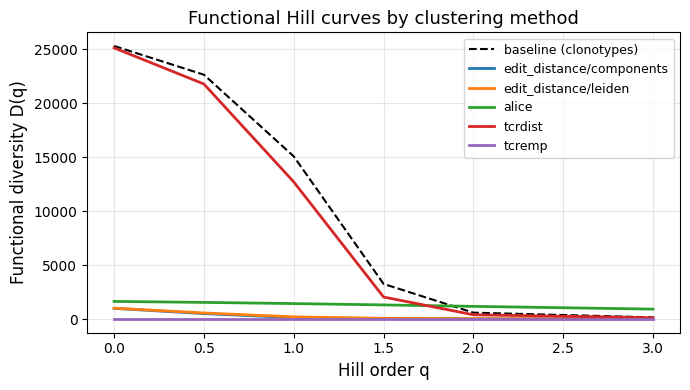

In [11]:
# Cell 11: Hill curves comparison across methods
q_values = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]

fig, ax = plt.subplots(figsize=(7, 4))

# Baseline Hill curve — column is 'hill'
hill_base = hill_curve_clonotypes(rep.clonotypes, q_values=q_values)
ax.plot(hill_base['q'], hill_base['hill'], 'k--', lw=1.5, label='baseline (clonotypes)')

colors = plt.cm.tab10.colors
for i, (method, (meta, _div, _)) in enumerate(results.items()):
    # Use the rep that was used for that method (alice uses rep_alice)
    r = rep_alice if method == 'alice' else rep
    try:
        hill = functional_hill_curve(r, meta, q_values=q_values)
        ax.plot(hill['q'], hill['hill'], color=colors[i % 10],
                lw=2, label=method)
    except Exception as exc:
        print(f'  Hill curve for {method} skipped: {exc}')

ax.set_xlabel('Hill order q', fontsize=12)
ax.set_ylabel('Functional diversity D(q)', fontsize=12)
ax.set_title('Functional Hill curves by clustering method', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

---
## Paired-chain analysis

For single-cell paired TRA/TRB data we can:
1. Use TCREmp's **native paired embedding** (`PairedTCREmp`) — joint representation of both chains.
2. Run **any single-chain method independently on each chain** then combine cluster IDs via
   `cluster_paired_metaclonotypes` → cluster ID = `"{TRA_cluster}.{TRB_cluster}"`.

Below we compare TCREmp-native paired vs TCRNET-combined on the same paired repertoire.

In [12]:
# Cell 12: Load paired TRA/TRB 10x data (skip gracefully if not available)
paired_rep = None

try:
    from mir.utils.notebook_assets import find_airr_benchmark_dcode_10x_vdj_v1_donor
    from mir.common.single_cell_parser import load_10x_vdj_v1_cell_clonotypes

    dcode_root = benchmark_root / 'dcode'
    if not dcode_root.exists():
        print('10x VDJ donor data not available (no dcode/ dir) — skipping paired analysis.')
    else:
        # Look for any donor
        all_contigs = sorted(dcode_root.glob('*all_contig_annotations.csv.gz'))
        if not all_contigs:
            print('No 10x contig files found — skipping paired analysis.')
        else:
            all_contig_path = all_contigs[0]
            # Derive matching consensus file
            consensus_candidates = sorted(dcode_root.glob(
                all_contig_path.name.replace('all_contig_annotations', 'consensus_annotations')
            )) or sorted(dcode_root.glob('*consensus_annotations.csv.gz'))
            consensus_path = consensus_candidates[0] if consensus_candidates else None
            if consensus_path is None:
                print('No consensus file found — skipping paired analysis.')
            else:
                from mir.common.single_cell import build_tenx_sample_from_cell_clonotypes
                cell_table = load_10x_vdj_v1_cell_clonotypes(
                    str(consensus_path), str(all_contig_path), sample_id='donor1',
                )
                sc_sample = build_tenx_sample_from_cell_clonotypes(cell_table, sample_id='donor1')
                tra_trb = sc_sample.paired_locus_repertoires.get('TRA_TRB')
                if tra_trb:
                    paired_rep = tra_trb
                    print(f'Loaded {len(tra_trb.paired_clonotypes)} TRA/TRB pairs')
                else:
                    print('No TRA_TRB pairs found.')
except Exception as exc:
    print(f'Paired data loading skipped: {exc}')

if paired_rep is None:
    print('Paired analysis cells will be skipped.')

Loaded 48890 TRA/TRB pairs


In [13]:
# Cell 13: Single-chain-combined paired metaclonotypes (edit-distance)
if paired_rep is not None:
    cfg_ed_paired = MetaclonotypeClusterConfig(
        method='edit_distance',
        metric='hamming',
        threshold=1,
        graph_algo='components',
        min_cluster_size=1,
        n_jobs=4,
    )
    t0 = time.perf_counter()
    meta_ed_paired = cluster_paired_metaclonotypes(paired_rep, cfg_ed_paired)
    t_ed = time.perf_counter() - t0
    print(f'Edit-distance combined: paired_clusters={meta_ed_paired.n_clusters}, '
          f'elapsed={t_ed:.2f}s')
else:
    print('Skipped: no paired repertoire.')

Edit-distance combined: paired_clusters=29315, elapsed=34.62s


In [ ]:
# Cell 14: Native paired TCREmp metaclonotypes (OPTICS)
if paired_rep is not None:
    cfg_tcremp_paired = MetaclonotypeClusterConfig(
        method='tcremp',
        locus_pair='TRA_TRB',
        species='human',
        n_prototypes=300,
        embed_cluster_algo='optics',
        optics_min_samples=5,
        n_jobs=4,
    )
    t0 = time.perf_counter()
    meta_tcremp_paired = cluster_paired_metaclonotypes(paired_rep, cfg_tcremp_paired)
    t_tcremp = time.perf_counter() - t0
    print(f'TCREmp native paired: paired_clusters={meta_tcremp_paired.n_clusters}, '
          f'elapsed={t_tcremp:.2f}s')
else:
    print('Skipped: no paired repertoire.')

In [15]:
# Cell 15: Concordance between TCREmp-native and edit-distance-combined
# Two paired metaclonotype sets are concordant if pairs assigned to the same
# cluster by method A are also largely co-clustered by method B.

if paired_rep is not None and 'meta_tcremp_paired' in dir():
    ed_t = meta_ed_paired.table.rename({'cluster_id': 'cluster_ed'})
    tcp_t = meta_tcremp_paired.table.rename({'cluster_id': 'cluster_tcremp'})

    joined = ed_t.join(
        tcp_t,
        on=['clonotype_id_1', 'clonotype_id_2'],
        how='inner',
    )

    # Cross-table: count pairs per (ed_cluster, tcremp_cluster)
    cross = (
        joined
        .group_by(['cluster_ed', 'cluster_tcremp'])
        .len()
        .sort('len', descending=True)
    )
    print(f'Pairs in both tables: {len(joined)}')
    print(f'Top 10 concordant cluster pairs:')
    print(cross.head(10))

    # Adjusted Rand Index for cluster agreement
    from sklearn.metrics import adjusted_rand_score

    # Create integer labels from cluster IDs for shared pairs
    ed_labels = joined['cluster_ed'].cast(pl.Categorical).to_physical().to_list()
    tcp_labels = joined['cluster_tcremp'].cast(pl.Categorical).to_physical().to_list()
    ari = adjusted_rand_score(ed_labels, tcp_labels)
    print(f'\nAdjusted Rand Index (edit_distance vs TCREmp): {ari:.4f}')
else:
    print('Skipped: paired reps not available.')

Pairs in both tables: 31458
Top 10 concordant cluster pairs:
shape: (10, 3)
┌────────────┬────────────────┬─────┐
│ cluster_ed ┆ cluster_tcremp ┆ len │
│ ---        ┆ ---            ┆ --- │
│ str        ┆ str            ┆ u32 │
╞════════════╪════════════════╪═════╡
│ 21.17      ┆ 0              ┆ 132 │
│ 18.15      ┆ 0              ┆ 91  │
│ 8.7        ┆ 0              ┆ 60  │
│ 56.49      ┆ 0              ┆ 60  │
│ 9.7        ┆ 0              ┆ 50  │
│ 20.17      ┆ 0              ┆ 49  │
│ 39.17      ┆ 0              ┆ 42  │
│ 68.61      ┆ 0              ┆ 25  │
│ 103.54     ┆ 0              ┆ 25  │
│ 394.172    ┆ 0              ┆ 24  │
└────────────┴────────────────┴─────┘

Adjusted Rand Index (edit_distance vs TCREmp): 0.0000


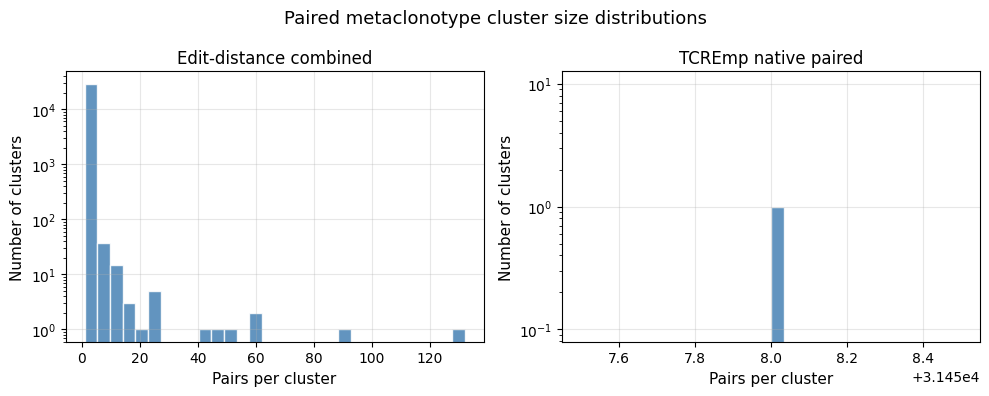

In [16]:
# Cell 16: Cluster size distribution comparison (paired methods)
if paired_rep is not None and 'meta_tcremp_paired' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
    for ax, (meta, label) in zip(
        axes,
        [(meta_ed_paired, 'Edit-distance combined'), (meta_tcremp_paired, 'TCREmp native paired')]
    ):
        sizes = (
            meta.table
            .group_by('cluster_id')
            .len()
            ['len']
            .to_list()
        )
        ax.hist(sizes, bins=30, edgecolor='white', color='steelblue', alpha=0.85)
        ax.set_title(label, fontsize=12)
        ax.set_xlabel('Pairs per cluster', fontsize=11)
        ax.set_ylabel('Number of clusters', fontsize=11)
        ax.set_yscale('log')
        ax.grid(alpha=0.3)

    fig.suptitle('Paired metaclonotype cluster size distributions', fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print('Skipped: paired reps not available.')

---
## Key takeaways

- **Edit-distance (components/Leiden)** — fastest, no pre-trained model; groups CDR3s differing by ≤1 Hamming substitution. ~4% of a bulk TRB repertoire clusters at threshold 1.
- **ALICE** — identifies statistically enriched ("convergent") clonotypes above Pgen-expected background. Finds ~6% of a bulk TRB repertoire as convergent; each cluster is independently enriched.
- **TCRdist** — V-gene germline alignment + CDR3 distance. At `max_distance=1200`, captures only the ~1% most similar pairs. **Best used on epitope-specific repertoires** where many TCRs target the same antigen and cluster at a shared threshold; on random bulk TRB it produces overwhelmingly singletons.
- **TCREmp** — learned prototype embeddings, L2-normalized before clustering. On a **bulk diverse repertoire**, the normalized embeddings are nearly uniformly distributed on the unit sphere and density-based clustering (OPTICS/DBSCAN) collapses to 1 mega-cluster or noise. **This is expected**: TCREmp is designed for cross-repertoire matching against antigen databases (e.g., VDJdb), not self-clustering of diverse bulk data.
- **Paired from single-chain** — `cluster_paired_metaclonotypes` applies any single-chain method per chain then combines IDs, making paired-chain analysis available for all methods.
- **TCREmp native paired** — joint TRA/TRB embedding; on diverse bulk data it has the same collapsing limitation as single-chain TCREmp.
- Concordance (ARI) between strategies reflects how similar their notions of clonotype similarity are. ARI=0 between edit-distance and TCREmp confirms they represent fundamentally different notions of similarity on random bulk data.